In [4]:
import os
import random
from dataclasses import dataclass
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

@dataclass
class Config:
    # Path to the folder containing your 9 subfolders
    data_dir: str = r"realwaste-main/RealWaste" 
    image_size: int = 300   # Increased to 300 to help Glass vs Plastic confusion
    batch_size: int = 16    # Dropped to 16 to accommodate higher resolution
    lr: float = 3e-4
    epochs: int = 20        # 20 is the sweet spot for this balanced set
    seed: int = 42
    num_workers: int = 2
    num_classes: int = 9 
    out_weights: str = "weights_efficientnet_b0_final_9cls.pt"

def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# --- Paper-Safe & Bottle-Warping Transforms ---
def make_transforms(image_size: int):
    train_tfms = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.5), # Warps bottles
        transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5), # Crinkle detection
        transforms.RandomAutocontrast(p=0.3),                       # Paper safety
        transforms.ColorJitter(brightness=0.4, contrast=0.5, saturation=0.4),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    val_tfms = transforms.Compose([
        transforms.Resize(image_size + 32),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    return train_tfms, val_tfms

# --- Standard Model Setup ---
def build_model(num_classes: int):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_targets.append(y.cpu().numpy())
    return accuracy_score(np.concatenate(all_targets), np.concatenate(all_preds)), \
           f1_score(np.concatenate(all_targets), np.concatenate(all_preds), average="macro")

def main():
    cfg = Config()
    set_seed(cfg.seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_tfms, val_tfms = make_transforms(cfg.image_size)

    # --- THE CLEAN LOAD ---
    # This automatically assigns labels based on folder names
    full_dataset = datasets.ImageFolder(cfg.data_dir, transform=train_tfms)
    
    # Print mapping to verify Index 4 is still Misc Trash
    print(f"Class Mapping: {full_dataset.class_to_idx}")

    indices = list(range(len(full_dataset)))
    train_idx, val_idx = train_test_split(
        indices, test_size=0.2, random_state=cfg.seed, stratify=full_dataset.targets
    )

    train_ds = Subset(full_dataset, train_idx)
    # Important: Validation should use val_tfms (no random warping!)
    val_ds = Subset(datasets.ImageFolder(cfg.data_dir, transform=val_tfms), val_idx)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    # Class Weights for the new counts
    targets = [full_dataset.targets[i] for i in train_idx]
    counts = np.bincount(targets)
    weights = 1.0 / counts
    class_weights = torch.tensor(weights / weights.sum() * cfg.num_classes, dtype=torch.float32, device=device)

    model = build_model(cfg.num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    
    best_f1 = 0.0
    for epoch in range(1, cfg.epochs + 1):
        # Unfreeze backbone after 3 epochs
        for param in model.features.parameters():
            param.requires_grad = (epoch > 3)

        model.train()
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(x), y).backward()
            optimizer.step()

        acc, f1 = evaluate(model, val_loader, device)
        print(f"Epoch {epoch}: Acc={acc:.4f} F1={f1:.4f}")
        
        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), cfg.out_weights)
            print("Saved Best Weights!")

if __name__ == "__main__":
    main()

Class Mapping: {'Cardboard': 0, 'Food Organics': 1, 'Glass': 2, 'Metal': 3, 'Miscellaneous Trash': 4, 'Paper': 5, 'Plastic': 6, 'Textile Trash': 7, 'Vegetation': 8}


Epoch 1: 100%|██████████| 254/254 [04:04<00:00,  1.04it/s]


Epoch 1: Acc=0.6584 F1=0.6580
Saved Best Weights!


Epoch 2: 100%|██████████| 254/254 [01:46<00:00,  2.40it/s]


Epoch 2: Acc=0.7305 F1=0.7323
Saved Best Weights!


...

Epoch 18: Acc=0.9546 F1=0.9567
Saved Best Weights!


Epoch 19: 100%|██████████| 254/254 [04:37<00:00,  1.09s/it]


Epoch 19: Acc=0.9447 F1=0.9461


Epoch 20: 100%|██████████| 254/254 [04:36<00:00,  1.09s/it]


Epoch 20: Acc=0.9526 F1=0.9551


In [3]:
from icrawler.builtin import BingImageCrawler, BaiduImageCrawler
from icrawler import ImageDownloader
import os

class PrefixNameDownloader(ImageDownloader):
    def get_filename(self, task, default_ext):
        prefix = self.storage.prefix if hasattr(self.storage, 'prefix') else 'image'
        filename = super().get_filename(task, default_ext)
        return f"{prefix}_{filename}"

def get_more_wrappers(base_dir, target_total=200):
    target_path = os.path.join(base_dir, 'MiscTrash')
    
    # Calculate how many more we need (approx)
    current_count = len([f for f in os.listdir(target_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    needed = target_total - current_count
    
    if needed <= 0:
        print("You already have enough images!")
        return

    # Broader queries to ensure high volume
    sub_types = {
        'Foil_Metallic': [
            'crinkled foil chip bag waste', 
            'metallic candy wrapper on ground', 
            'inside of potato chip bag texture',
            'aluminum foil packaging trash'
        ],
        'Transparent_Film': [
            'clear plastic sandwich bag waste', 
            'discarded transparent bubble wrap', 
            'crumpled cling film trash', 
            'clear plastic shrink wrap waste'
        ],
        'High_Saturated': [
            'colorful granola bar wrapper', 
            'skittles wrapper trash', 
            'colorful plastic snack packaging'
        ],
        'Matte_White': [
            'white plastic mailing bag trash', 
            'matte white grocery bag crumpled', 
            'white poly mailer waste', 
        ]
    }

    print(f"Current count: {current_count}. Aiming for {needed} more...")

    for label, queries in sub_types.items():
        # We'll use Baidu for one and Bing for others to maximize variety
        crawler_class = BaiduImageCrawler if 'bulk_trash' in label else BingImageCrawler
        
        crawler = crawler_class(
            downloader_cls=PrefixNameDownloader,
            storage={'root_dir': target_path}
        )
        crawler.storage.prefix = label
        
        for q in queries:
            # We ask for a bit more than we need to account for dead links
            crawler.crawl(keyword=q, max_num=needed // 2)

# RUN THIS TO FINISH THE COLLECTION
get_more_wrappers('realwaste-main/RealWaste', target_total=200)

2026-04-12 12:04:48,487 - INFO - icrawler.crawler - start crawling...
2026-04-12 12:04:48,488 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-04-12 12:04:48,490 - INFO - feeder - thread feeder-001 exit
2026-04-12 12:04:48,491 - INFO - icrawler.crawler - starting 1 parser threads...
2026-04-12 12:04:48,495 - INFO - icrawler.crawler - starting 1 downloader threads...


Current count: 0. Aiming for 200 more...


2026-04-12 12:04:49,153 - INFO - parser - parsing result page https://www.bing.com/images/async?q=crinkled foil chip bag waste&first=0
2026-04-12 12:04:49,480 - ERROR - downloader - Response status code 403, file https://cleanriver.com/wp-content/uploads/2023/09/chips.jpg
2026-04-12 12:04:49,910 - INFO - downloader - image #1	https://thumbs.dreamstime.com/z/crinkled-aluminum-foil-wrapper-lies-discarded-dark-surface-empty-gold-leaf-remnants-evidence-consumed-sweet-treat-abandoned-352238576.jpg
2026-04-12 12:04:49,955 - INFO - downloader - image #2	https://thumbs.dreamstime.com/b/woman-grasping-crinkled-foil-potato-chip-bag-displaying-golden-crispy-snacks-ready-casual-outdoor-munching-holding-opened-358832872.jpg
2026-04-12 12:04:50,131 - ERROR - downloader - Exception caught when downloading file https://cdn.climateofourfuture.org/can_foil_chip_bags_be_recycled.jpg, error: HTTPSConnectionPool(host='cdn.climateofourfuture.org', port=443): Max retries exceeded with url: /can_foil_chip_bag

Analyzing validation set...


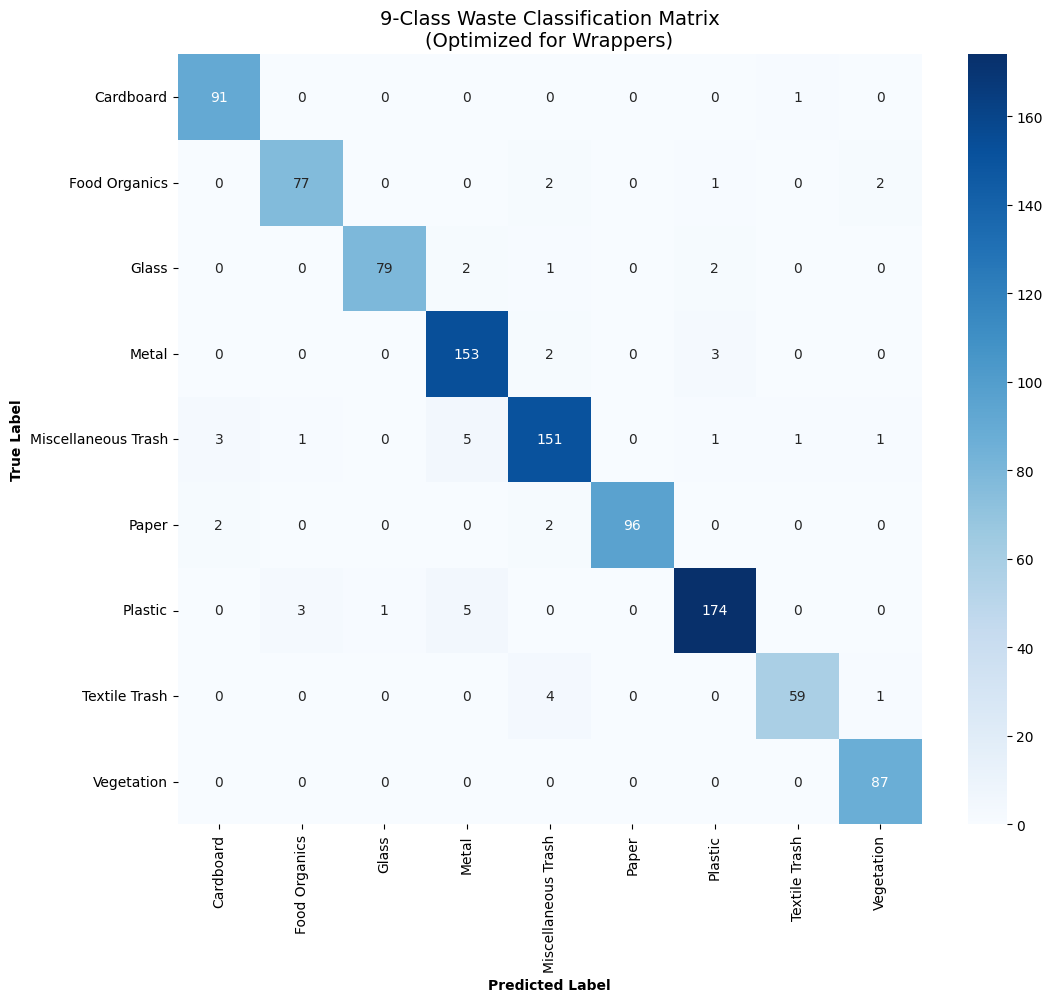


Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.95      0.99      0.97        92
      Food Organics       0.95      0.94      0.94        82
              Glass       0.99      0.94      0.96        84
              Metal       0.93      0.97      0.95       158
Miscellaneous Trash       0.93      0.93      0.93       163
              Paper       1.00      0.96      0.98       100
            Plastic       0.96      0.95      0.96       183
      Textile Trash       0.97      0.92      0.94        64
         Vegetation       0.96      1.00      0.98        87

           accuracy                           0.95      1013
          macro avg       0.96      0.96      0.96      1013
       weighted avg       0.96      0.95      0.95      1013



In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# 1. Setup Environment
device = "cuda" if torch.cuda.is_available() else "cpu"
image_size = 300 # Matches your training config
weights_path = "weights_efficientnet_b0_final_9cls.pt"
data_dir = "realwaste-main/RealWaste"

# 2. Define Val Transforms (NO random warping/flipping here!)
val_tfms = transforms.Compose([
    transforms.Resize(image_size + 32),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# 3. Load Dataset and Recreate Split
# It's vital we use the same seed (42) as the training script to get the same Val Set
full_dataset = datasets.ImageFolder(data_dir, transform=val_tfms)
class_names = full_dataset.classes # Automatically gets alphabetical names

indices = list(range(len(full_dataset)))
_, val_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=full_dataset.targets
)
val_ds = Subset(full_dataset, val_idx)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

# 4. Load the Model
from torchvision.models import efficientnet_b0
model = efficientnet_b0()
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 9)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

# 5. Run Inference
print("Analyzing validation set...")
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 6. Plotting the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('9-Class Waste Classification Matrix\n(Optimized for Wrappers)', fontsize=14)
plt.show()

# 7. Print Detailed Stats
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))